# Group-Aware Running Injury Risk Prediction

## Objective

The objective of this notebook is to predict whether a competitive runner's
training-history record is associated with an injury outcome.

The notebook investigates:

- the severity of the injury-class imbalance;
- whether a class-weighted Random Forest can detect rare injury cases;
- how random row splitting differs from runner-grouped splitting;
- how the probability threshold affects injury recall and false alerts;
- which training-history features are most important;
- whether performance varies across unseen test runners.

## Why grouped validation matters

The dataset contains repeated records from the same runners. Under an ordinary
random split, records from one runner may appear in both training and test
sets.

The model may then partially recognise runner-specific patterns instead of
learning relationships that generalise to new athletes.

A grouped split keeps every runner entirely within one subset:

- training runners;
- validation runners;
- test runners.

The test set therefore measures performance on completely unseen runners.

## Important limitation

This notebook is an educational machine-learning experiment. Its predictions
must not be treated as medical diagnoses or used independently to determine
whether an athlete should train, compete or receive treatment.

In [ ]:
from pathlib import Path

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn import set_config
from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    fbeta_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score
)
from sklearn.model_selection import (
    StratifiedGroupKFold,
    train_test_split
)
from sklearn.pipeline import Pipeline

sns.set_theme(style="whitegrid")
set_config(display="text")

RANDOM_STATE = 42

c:\Users\ADMIN\AppData\Local\Programs\Python\Python311\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.4.0) or chardet (7.4.3)/charset_normalizer (3.4.2) doesn't match a supported version!
  warnings.warn(


In [2]:
dataset_path = Path(
    kagglehub.dataset_download(
        "shashwatwork/"
        "injury-prediction-for-competitive-runners"
    )
)

csv_files = sorted(
    dataset_path.rglob("*.csv")
)

print("CSV files found:")

for csv_path in csv_files:
    print(
        "-",
        csv_path.relative_to(
            dataset_path
        )
    )

100%|██████████| 2.49M/2.49M [00:01<00:00, 2.13MB/s]

Extracting files...


CSV files found:
- day_approach_maskedID_timeseries.csv
- week_approach_maskedID_timeseries.csv


In [4]:
def normalise_column_name(column_name):
    return (
        str(column_name)
        .strip()
        .lower()
        .replace(".", "_")
        .replace("-", "_")
        .replace(" ", "_")
    )


candidate_files = []

for csv_path in csv_files:
    sample_df = pd.read_csv(
        csv_path,
        nrows=5
    )

    normalised_columns = {
        normalise_column_name(column)
        for column in sample_df.columns
    }

    if {
        "injury",
        "athlete_id"
    }.issubset(normalised_columns):
        candidate_files.append(
            csv_path
        )

if not candidate_files:
    raise FileNotFoundError(
        "No CSV containing both 'injury' "
        "and 'Athlete ID' was found."
    )

# Prefer the largest matching CSV
data_path = max(
    candidate_files,
    key=lambda path:
        path.stat().st_size
)

raw_runner_df = pd.read_csv(
    data_path
)

print(f"Selected file: {data_path}")
print(
    "Raw dataset shape:",
    raw_runner_df.shape
)

raw_runner_df.head()

Selected file: C:\Users\ADMIN\.cache\kagglehub\datasets\shashwatwork\injury-prediction-for-competitive-runners\versions\1\week_approach_maskedID_timeseries.csv
Raw dataset shape: (42798, 72)


,nr. sessions,nr. rest days,total kms,max km one day,total km Z3-Z4-Z5-T1-T2,"nr. tough sessions (effort in Z5, T1 or T2)",nr. days with interval session,total km Z3-4,max km Z3-4 one day,total km Z5-T1-T2,...,max training success.2,avg recovery.2,min recovery.2,max recovery.2,Athlete ID,injury,rel total kms week 0_1,rel total kms week 0_2,rel total kms week 1_2,Date
0,5.0,2.0,22.2,16.4,11.8,1.0,2.0,10.0,10.0,0.6,...,0.0,0.18,0.16,0.20,0,0,0.718447,1.378882,1.919255,0
1,5.0,2.0,21.6,16.4,11.7,1.0,2.0,10.0,10.0,0.5,...,0.0,0.18,0.16,0.20,0,0,0.683544,1.018868,1.490566,1
2,5.0,2.0,21.6,16.4,11.7,1.0,2.0,10.0,10.0,0.5,...,0.0,0.17,0.16,0.18,0,0,0.683544,1.018868,1.490566,2
3,5.0,2.0,21.6,16.4,11.7,1.0,2.0,10.0,10.0,0.5,...,0.0,0.18,0.16,0.18,0,0,0.683544,1.018868,1.490566,3
4,6.0,1.0,39.2,17.6,18.9,1.0,3.0,17.2,10.0,0.5,...,0.0,0.17,0.16,0.18,0,0,2.202247,1.361111,0.618056,4


In [5]:
raw_runner_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42798 entries, 0 to 42797
Data columns (total 72 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   nr. sessions                                   42798 non-null  float64
 1   nr. rest days                                  42798 non-null  float64
 2   total kms                                      42798 non-null  float64
 3   max km one day                                 42798 non-null  float64
 4   total km Z3-Z4-Z5-T1-T2                        42798 non-null  float64
 5   nr. tough sessions (effort in Z5, T1 or T2)    42798 non-null  float64
 6   nr. days with interval session                 42798 non-null  float64
 7   total km Z3-4                                  42798 non-null  float64
 8   max km Z3-4 one day                            42798 non-null  float64
 9   total km Z5-T1-T2                              427

In [6]:
raw_runner_df.describe(
    include="all"
).T

,count,mean,std,min,25%,50%,75%,max
nr. sessions,42798.0,5.809337,2.484234e+00,0.0,5.000000,6.000000,7.000000,14.0
nr. rest days,42798.0,1.874667,1.853287e+00,0.0,1.000000,1.000000,3.000000,7.0
total kms,42798.0,49.543911,3.671502e+01,0.0,22.800000,44.800000,70.100000,242.0
max km one day,42798.0,14.009255,9.071678e+00,0.0,9.000000,13.400000,18.300000,131.0
total km Z3-Z4-Z5-T1-T2,42798.0,9.433621,8.887120e+00,0.0,1.000000,8.000000,14.600000,100.0
...,...,...,...,...,...,...,...,...
injury,42798.0,0.013435,1.151304e-01,0.0,0.000000,0.000000,0.000000,1.0
rel total kms week 0_1,42798.0,440862.770299,4.328234e+06,0.0,0.695524,0.989186,1.320515,209600000.0
rel total kms week 0_2,42798.0,901468.491355,6.945503e+06,0.0,0.672397,1.001431,1.422171,217600000.0
rel total kms week 1_2,42798.0,480362.288936,4.656806e+06,0.0,0.692308,0.989752,1.327586,209600000.0


### Initial dataset observations

The selected weekly dataset contains 42,798 observations and 72 columns from
74 competitive runners. Each row contains a runner's recent training history
together with a binary injury outcome.

The model variables include:

- number of training and rest days;
- total weekly running distance;
- maximum distance completed in one day;
- distance completed in different intensity zones;
- interval and difficult training sessions;
- strength and alternative training;
- perceived exertion;
- training success;
- recovery measurements.

Many measurements appear in three repeated blocks. The original feature,
`.1` feature and `.2` feature represent measurements from different weekly
history periods. Three additional variables compare relative weekly running
distance across these periods.

The injury target contains the values 0 and 1. There were no missing values
in the raw dataset.

Several relative-distance variables contained extremely large maximum values,
reaching more than 200 million despite medians close to 1. These values were
probably produced when current mileage was divided by extremely small or zero
mileage in another week. They should be treated as potential data-quality
outliers.

The `Date` field was a numerical sequence ranging from 0 to 2,673 rather than
a directly interpretable calendar date. It was excluded from model training.

In [7]:
runner_df = raw_runner_df.copy()

runner_df.columns = [
    normalise_column_name(column)
    for column in runner_df.columns
]

# Remove exported index columns, if present
unnamed_columns = [
    column
    for column in runner_df.columns
    if column.startswith("unnamed")
]

runner_df = runner_df.drop(
    columns=unnamed_columns,
    errors="ignore"
)

print(
    "Normalised columns:",
    runner_df.columns.tolist()
)

Normalised columns: ['nr__sessions', 'nr__rest_days', 'total_kms', 'max_km_one_day', 'total_km_z3_z4_z5_t1_t2', 'nr__tough_sessions_(effort_in_z5,_t1_or_t2)', 'nr__days_with_interval_session', 'total_km_z3_4', 'max_km_z3_4_one_day', 'total_km_z5_t1_t2', 'max_km_z5_t1_t2_one_day', 'total_hours_alternative_training', 'nr__strength_trainings', 'avg_exertion', 'min_exertion', 'max_exertion', 'avg_training_success', 'min_training_success', 'max_training_success', 'avg_recovery', 'min_recovery', 'max_recovery', 'nr__sessions_1', 'nr__rest_days_1', 'total_kms_1', 'max_km_one_day_1', 'total_km_z3_z4_z5_t1_t2_1', 'nr__tough_sessions_(effort_in_z5,_t1_or_t2)_1', 'nr__days_with_interval_session_1', 'total_km_z3_4_1', 'max_km_z3_4_one_day_1', 'total_km_z5_t1_t2_1', 'max_km_z5_t1_t2_one_day_1', 'total_hours_alternative_training_1', 'nr__strength_trainings_1', 'avg_exertion_1', 'min_exertion_1', 'max_exertion_1', 'avg_training_success_1', 'min_training_success_1', 'max_training_success_1', 'avg_reco

In [ ]:
TARGET_COLUMN = "injury"
GROUP_COLUMN = "athlete_id"

runner_df[TARGET_COLUMN] = pd.to_numeric(
    runner_df[TARGET_COLUMN],
    errors="coerce"
)

runner_df = runner_df[
    runner_df[TARGET_COLUMN].isin(
        [0, 1]
    )
].copy()

runner_df[TARGET_COLUMN] = (
    runner_df[TARGET_COLUMN]
    .astype(int)
)

date_column = (
    "date"
    if "date" in runner_df.columns
    else None
)

if date_column is not None:
    runner_df[date_column] = pd.to_datetime(
        runner_df[date_column],
        errors="coerce"
    )

duplicate_count = (
    runner_df.duplicated().sum()
)

runner_df = (
    runner_df
    .drop_duplicates()
    .reset_index(drop=True)
)

print(
    "Cleaned dataset shape:",
    runner_df.shape
)
print(
    "Duplicate rows removed:",
    duplicate_count
)
print(
    "Unique athletes:",
    runner_df[
        GROUP_COLUMN
    ].nunique()
)

Cleaned dataset shape: (42798, 72)
Duplicate rows removed: 0
Unique athletes: 74


In [9]:
excluded_columns = [
    TARGET_COLUMN,
    GROUP_COLUMN
]

if date_column is not None:
    excluded_columns.append(
        date_column
    )

X = runner_df.drop(
    columns=excluded_columns
)

# Training-history variables should be numeric
X = X.apply(
    pd.to_numeric,
    errors="coerce"
)

all_missing_columns = (
    X.columns[
        X.isna().all()
    ].tolist()
)

X = X.drop(
    columns=all_missing_columns
)

y = runner_df[TARGET_COLUMN]

athlete_groups = runner_df[
    GROUP_COLUMN
]

print("Model feature shape:", X.shape)
print(
    "All-missing columns removed:",
    all_missing_columns
)
print(
    "Remaining missing values:",
    int(X.isna().sum().sum())
)

Model feature shape: (42798, 69)
All-missing columns removed: []
Remaining missing values: 0


### Data cleaning 

The cleaned dataset retained all 42,798 observations. No duplicate rows were
found and no rows required removal.

The data contained:

- 74 unique runners;
- 69 numerical model features;
- no remaining missing values;
- no entirely missing columns.

The injury target was encoded as:

- 0: no recorded injury;
- 1: recorded injury.

`athlete_id` was excluded from the model because it is an identifier rather
than a training measurement. However, it was retained separately to ensure
that records from one runner could not appear in multiple data subsets.

The numerical `date` column was also excluded. The final predictors contained
only training-load, exertion, recovery and related historical measurements.

In [10]:
class_summary_df = (
    y.value_counts()
    .sort_index()
    .rename_axis("injury")
    .reset_index(name="observations")
)

class_summary_df["percentage"] = (
    class_summary_df["observations"]
    / len(y)
    * 100
)

class_summary_df

,injury,observations,percentage
0,0,42223,98.656479
1,1,575,1.343521


In [11]:
athlete_summary_df = (
    runner_df
    .groupby(
        GROUP_COLUMN,
        observed=True
    )
    .agg(
        records=(
            TARGET_COLUMN,
            "size"
        ),
        injuries=(
            TARGET_COLUMN,
            "sum"
        ),
        injury_rate=(
            TARGET_COLUMN,
            "mean"
        )
    )
    .sort_values(
        "records",
        ascending=False
    )
    .reset_index()
)

athlete_summary_df.describe().T

,count,mean,std,min,25%,50%,75%,max
athlete_id,74.0,36.500000,21.505813,0.0,18.250000,36.500000,54.7500,73.000000
records,74.0,578.351351,426.866487,43.0,269.000000,426.500000,753.0000,1791.000000
injuries,74.0,7.770270,8.281928,0.0,2.000000,5.000000,11.5000,35.000000
injury_rate,74.0,0.012561,0.011176,0.0,0.004073,0.010238,0.0177,0.045205


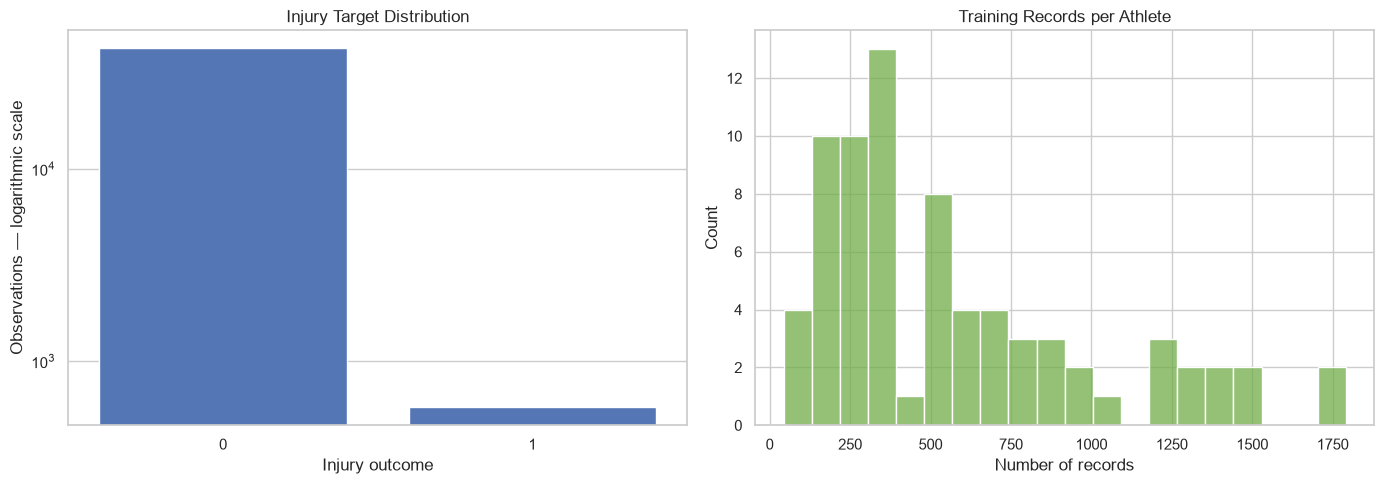

In [12]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

sns.barplot(
    data=class_summary_df,
    x="injury",
    y="observations",
    color="#4472C4",
    ax=axes[0]
)

axes[0].set_yscale("log")
axes[0].set_title(
    "Injury Target Distribution"
)
axes[0].set_xlabel("Injury outcome")
axes[0].set_ylabel(
    "Observations — logarithmic scale"
)

sns.histplot(
    data=athlete_summary_df,
    x="records",
    bins=20,
    color="#70AD47",
    ax=axes[1]
)

axes[1].set_title(
    "Training Records per Athlete"
)
axes[1].set_xlabel(
    "Number of records"
)

plt.tight_layout()
plt.show()

In [13]:
athletes_with_injuries = (
    athlete_summary_df[
        athlete_summary_df[
            "injuries"
        ] > 0
    ]
)

print(
    "Athletes with at least one injury:",
    len(athletes_with_injuries)
)

print(
    "Athletes without recorded injuries:",
    (
        len(athlete_summary_df)
        - len(athletes_with_injuries)
    )
)

athlete_summary_df.sort_values(
    "injuries",
    ascending=False
).head(15)

Athletes with at least one injury: 61
Athletes without recorded injuries: 13


,athlete_id,records,injuries,injury_rate
14,26,884,35,0.039593
20,29,730,33,0.045205
19,42,744,32,0.043011
4,23,1393,24,0.017229
9,9,1232,22,0.017857
6,27,1344,22,0.016369
24,36,638,22,0.034483
2,22,1478,21,0.014208
5,41,1393,18,0.012922
16,38,843,18,0.021352


### Class imbalance 

The target was extremely imbalanced:

- No injury: 42,223 observations, or 98.66%;
- Injury: 575 observations, or 1.34%.

There were approximately 73 non-injury records for every injury record. A
model predicting no injury for every observation would therefore achieve
approximately 98.7% accuracy while identifying no injuries.

Of the 74 runners:

- 61 had at least one recorded injury;
- 13 had no recorded injuries.

The number of records contributed by each runner also varied considerably,
from 43 to 1,791. The median runner contributed 426.5 records. Injury counts
ranged from 0 to 35, and the highest runner-level injury rate was
approximately 4.52%.

These differences mean that runners contributing many observations can have
greater influence on the model.

Accuracy is not an appropriate primary metric for this problem. Recall,
precision, F2-score and average precision are more informative because they
measure whether the rare injury cases are detected and how many alerts are
false.

In [19]:
feature_target_correlations = (
    X.corrwith(y)
    .dropna()
)

top_correlation_names = (
    feature_target_correlations
    .abs()
    .nlargest(15)
    .index
)

top_correlations_df = (
    feature_target_correlations
    .loc[top_correlation_names]
    .sort_values()
    .rename("correlation")
    .reset_index()
    .rename(
        columns={
            "index": "feature"
        }
    )
)

top_correlations_df

,feature,correlation
0,avg_training_success_1,0.033339
1,avg_recovery,0.033640
2,max_recovery_2,0.034062
3,max_training_success_2,0.034510
4,avg_training_success,0.035395
5,max_training_success_1,0.035923
6,max_recovery_1,0.036539
7,max_training_success,0.038485
8,avg_exertion_2,0.038910
9,max_exertion_2,0.040890


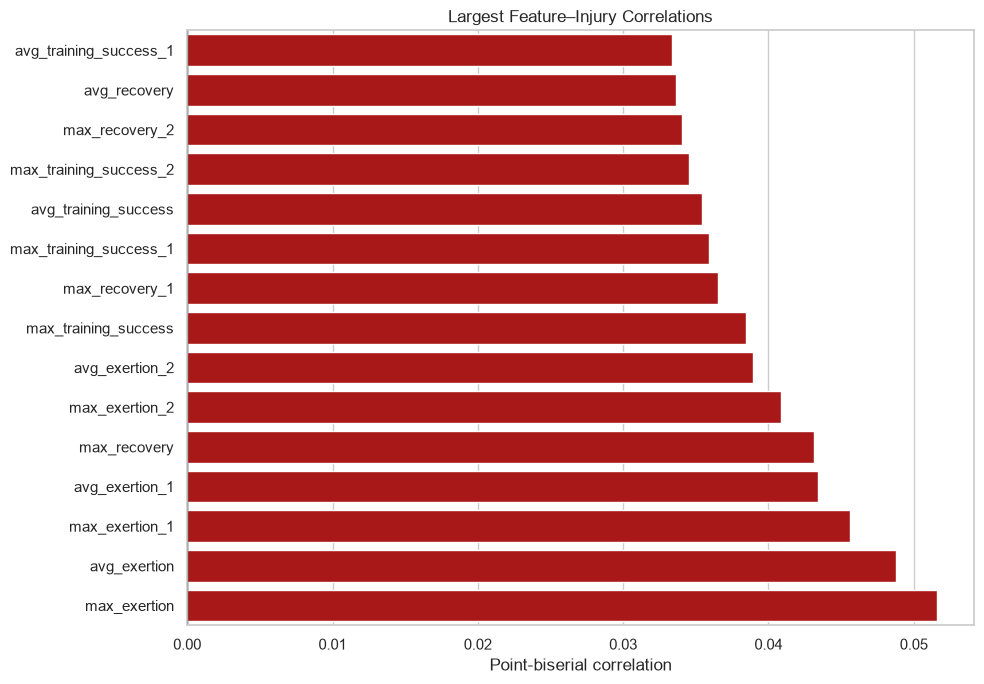

In [20]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_correlations_df,
    x="correlation",
    y="feature",
    hue=(
        top_correlations_df[
            "correlation"
        ] >= 0
    ),
    palette={
        True: "#C00000",
        False: "#4472C4"
    },
    dodge=False
)

plt.axvline(
    0,
    color="black",
    linewidth=1
)

plt.title(
    "Largest Feature–Injury Correlations"
)
plt.xlabel("Point-biserial correlation")
plt.ylabel("")
plt.legend([], [], frameon=False)
plt.tight_layout()
plt.show()

### Exploratory feature findings

All 15 of the largest absolute feature correlations with injury were
positive, but they were extremely weak. The strongest were:

- Current maximum exertion: 0.0516;
- Current average exertion: 0.0488;
- Previous-period maximum exertion: 0.0456;
- Previous-period average exertion: 0.0434;
- Current maximum recovery: 0.0432;
- Older-period maximum exertion: 0.0409.

Training-success and recovery variables also appeared among the strongest
correlations, but none exceeded approximately 0.052.

The results suggest that exertion-related measurements contain some injury
signal, but no individual variable has a strong linear relationship with the
target. Injury risk is likely influenced by complex interactions, individual
runner differences and factors not represented in the dataset.

Positive correlations involving recovery or training success should not be
interpreted as evidence that better recovery causes injury. The variables may
use a particular subjective scale, interact with training load, or reflect
runner-specific reporting behaviour.

In [21]:
outer_splitter = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

development_indices, test_indices = next(
    outer_splitter.split(
        X,
        y,
        groups=athlete_groups
    )
)

X_development = X.iloc[
    development_indices
]

X_test = X.iloc[
    test_indices
]

y_development = y.iloc[
    development_indices
]

y_test = y.iloc[
    test_indices
]

groups_development = athlete_groups.iloc[
    development_indices
]

groups_test = athlete_groups.iloc[
    test_indices
]

In [22]:
inner_splitter = StratifiedGroupKFold(
    n_splits=4,
    shuffle=True,
    random_state=RANDOM_STATE + 1
)

train_relative_indices, validation_relative_indices = next(
    inner_splitter.split(
        X_development,
        y_development,
        groups=groups_development
    )
)

X_train = X_development.iloc[
    train_relative_indices
]

X_validation = X_development.iloc[
    validation_relative_indices
]

y_train = y_development.iloc[
    train_relative_indices
]

y_validation = y_development.iloc[
    validation_relative_indices
]

groups_train = groups_development.iloc[
    train_relative_indices
]

groups_validation = groups_development.iloc[
    validation_relative_indices
]

In [23]:
split_summary_df = pd.DataFrame(
    [
        {
            "subset": "Training",
            "observations": len(y_train),
            "athletes":
                groups_train.nunique(),
            "injuries": int(
                y_train.sum()
            ),
            "injury_rate":
                y_train.mean()
        },
        {
            "subset": "Validation",
            "observations":
                len(y_validation),
            "athletes":
                groups_validation.nunique(),
            "injuries": int(
                y_validation.sum()
            ),
            "injury_rate":
                y_validation.mean()
        },
        {
            "subset": "Test",
            "observations": len(y_test),
            "athletes":
                groups_test.nunique(),
            "injuries": int(
                y_test.sum()
            ),
            "injury_rate":
                y_test.mean()
        }
    ]
)

split_summary_df

,subset,observations,athletes,injuries,injury_rate
0,Training,25727,46,344,0.013371
1,Validation,8545,14,117,0.013692
2,Test,8526,14,114,0.013371


In [24]:
train_athletes = set(
    groups_train.unique()
)

validation_athletes = set(
    groups_validation.unique()
)

test_athletes = set(
    groups_test.unique()
)

print(
    "Train/validation overlap:",
    len(
        train_athletes
        & validation_athletes
    )
)

print(
    "Train/test overlap:",
    len(
        train_athletes
        & test_athletes
    )
)

print(
    "Validation/test overlap:",
    len(
        validation_athletes
        & test_athletes
    )
)

Train/validation overlap: 0
Train/test overlap: 0
Validation/test overlap: 0


### Grouped split 

The runner-grouped data subsets were:

| Subset | Observations | Runners | Injuries | Injury rate |
|---|---:|---:|---:|---:|
| Training | 25,727 | 46 | 344 | 1.34% |
| Validation | 8,545 | 14 | 117 | 1.37% |
| Test | 8,526 | 14 | 114 | 1.34% |

There was no athlete overlap between any pair of subsets. Every runner
appeared exclusively in training, validation or testing.

The injury rates were also very similar across the subsets, showing that
`StratifiedGroupKFold` maintained the class distribution while preserving
runner separation.

This provides a substantially more realistic evaluation than random row
splitting. The test results measure whether the model can generalise to
runners whose training records were never observed during training.

In [25]:
preprocessor = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        )
    ]
)

baseline_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            clone(preprocessor)
        ),
        (
            "classifier",
            DummyClassifier(
                strategy="most_frequent"
            )
        )
    ]
)

random_forest_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            clone(preprocessor)
        ),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=300,
                max_features="sqrt",
                min_samples_leaf=2,
                class_weight=
                    "balanced_subsample",
                random_state=RANDOM_STATE,
                n_jobs=-1
            )
        )
    ]
)

## Why use class weighting?

Injury observations are rare. Without adjustment, a classifier may minimise
its total errors by predicting almost every observation as non-injury.

`class_weight="balanced_subsample"` gives injury cases greater influence when
each tree is trained. It does not create synthetic athlete records or copy
minority observations.

In [26]:
all_indices = np.arange(
    len(X)
)

random_train_indices, random_test_indices = train_test_split(
    all_indices,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

random_split_model = clone(
    random_forest_pipeline
)

random_split_model.fit(
    X.iloc[random_train_indices],
    y.iloc[random_train_indices]
)

random_probabilities = (
    random_split_model
    .predict_proba(
        X.iloc[random_test_indices]
    )[:, 1]
)

random_predictions = (
    random_probabilities >= 0.50
).astype(int)

In [27]:
grouped_comparison_model = clone(
    random_forest_pipeline
)

grouped_comparison_model.fit(
    X_development,
    y_development
)

grouped_probabilities = (
    grouped_comparison_model
    .predict_proba(X_test)[:, 1]
)

grouped_predictions = (
    grouped_probabilities >= 0.50
).astype(int)

In [28]:
def calculate_metrics(
    evaluation_name,
    y_true,
    predictions,
    probabilities
):
    return {
        "evaluation": evaluation_name,
        "accuracy": accuracy_score(
            y_true,
            predictions
        ),
        "balanced_accuracy":
            balanced_accuracy_score(
                y_true,
                predictions
            ),
        "precision": precision_score(
            y_true,
            predictions,
            zero_division=0
        ),
        "recall": recall_score(
            y_true,
            predictions,
            zero_division=0
        ),
        "f1": f1_score(
            y_true,
            predictions,
            zero_division=0
        ),
        "f2": fbeta_score(
            y_true,
            predictions,
            beta=2,
            zero_division=0
        ),
        "roc_auc": roc_auc_score(
            y_true,
            probabilities
        ),
        "average_precision":
            average_precision_score(
                y_true,
                probabilities
            )
    }

In [29]:
split_comparison_df = pd.DataFrame(
    [
        calculate_metrics(
            "Random row split",
            y.iloc[
                random_test_indices
            ],
            random_predictions,
            random_probabilities
        ),
        calculate_metrics(
            "Runner-grouped split",
            y_test,
            grouped_predictions,
            grouped_probabilities
        )
    ]
)

split_comparison_df

,evaluation,accuracy,balanced_accuracy,precision,recall,f1,f2,roc_auc,average_precision
0,Random row split,0.986565,0.5,0.0,0.0,0.0,0.0,0.759340,0.035025
1,Runner-grouped split,0.986629,0.5,0.0,0.0,0.0,0.0,0.514938,0.013380


In [30]:
random_train_athletes = set(
    athlete_groups.iloc[
        random_train_indices
    ].unique()
)

random_test_athletes = set(
    athlete_groups.iloc[
        random_test_indices
    ].unique()
)

print(
    "Athletes appearing in both random "
    "training and test sets:",
    len(
        random_train_athletes
        & random_test_athletes
    )
)

print(
    "Athletes appearing in both grouped "
    "development and test sets:",
    len(
        set(groups_development.unique())
        & set(groups_test.unique())
    )
)

Athletes appearing in both random training and test sets: 74
Athletes appearing in both grouped development and test sets: 0


### Split strategy comparison

| Evaluation | ROC-AUC | Average precision | Recall at 0.50 |
|---|---:|---:|---:|
| Random row split | 0.759 | 0.0350 | 0.0% |
| Runner-grouped split | 0.515 | 0.0134 | 0.0% |

Under random splitting, all 74 athletes appeared in both the training and
test sets. Under grouped evaluation, athlete overlap was zero.

Both models predicted no injuries at the default threshold of 0.50, producing
98.66% accuracy but zero precision, recall, F1 and F2. The high accuracy was
entirely caused by the dominant non-injury class.

However, the threshold-independent metrics revealed a major difference. ROC-
AUC declined from 0.759 under random splitting to 0.515 under grouped
splitting. Average precision declined from 3.50% to 1.34%.

The grouped average precision was approximately equal to the test injury
prevalence. This means the probability ranking provided almost no improvement
over a random ranking for unseen runners.

Random splitting therefore produced substantially more optimistic results,
probably because the model could learn athlete-specific patterns from other
records belonging to the same runners. Even the random-split average
precision remained low in absolute terms because injuries were extremely
rare.

In [31]:
baseline_pipeline.fit(
    X_train,
    y_train
)

random_forest_pipeline.fit(
    X_train,
    y_train
)

baseline_validation_probabilities = (
    baseline_pipeline
    .predict_proba(
        X_validation
    )[:, 1]
)

baseline_validation_predictions = (
    baseline_pipeline
    .predict(X_validation)
)

forest_validation_probabilities = (
    random_forest_pipeline
    .predict_proba(
        X_validation
    )[:, 1]
)

forest_default_validation_predictions = (
    forest_validation_probabilities
    >= 0.50
).astype(int)

validation_evaluation_df = pd.DataFrame(
    [
        calculate_metrics(
            "Majority baseline",
            y_validation,
            baseline_validation_predictions,
            baseline_validation_probabilities
        ),
        calculate_metrics(
            "Random Forest — threshold 0.50",
            y_validation,
            forest_default_validation_predictions,
            forest_validation_probabilities
        )
    ]
)

validation_evaluation_df

,evaluation,accuracy,balanced_accuracy,precision,recall,f1,f2,roc_auc,average_precision
0,Majority baseline,0.986308,0.5,0.0,0.0,0.0,0.0,0.500000,0.013692
1,Random Forest — threshold 0.50,0.986308,0.5,0.0,0.0,0.0,0.0,0.604894,0.017514


### Validation performance 

At the default threshold of 0.50, both the majority baseline and Random Forest
predicted every validation observation as non-injury.

Their default-threshold results were therefore identical:

- Accuracy: 98.63%;
- Balanced accuracy: 50%;
- Precision: 0%;
- Recall: 0%;
- F1 and F2: 0.

The Random Forest's ROC-AUC was 0.605, compared with 0.500 for the baseline.
Its average precision was 1.75%, only slightly above the validation injury
prevalence of 1.37%.

The model therefore contained a small amount of ranking information on the
validation runners, but its probabilities never crossed the default 0.50
decision threshold. The default threshold was unsuitable for detecting this
rare outcome.

In [32]:
(
    threshold_precisions,
    threshold_recalls,
    candidate_thresholds
) = precision_recall_curve(
    y_validation,
    forest_validation_probabilities
)

# The final precision and recall values do not
# correspond to a threshold
threshold_precisions = (
    threshold_precisions[:-1]
)

threshold_recalls = (
    threshold_recalls[:-1]
)

f2_values = (
    5
    * threshold_precisions
    * threshold_recalls
    / (
        4 * threshold_precisions
        + threshold_recalls
        + 1e-12
    )
)

threshold_analysis_df = pd.DataFrame(
    {
        "threshold":
            candidate_thresholds,
        "precision":
            threshold_precisions,
        "recall":
            threshold_recalls,
        "f2":
            f2_values
    }
)

best_threshold_row = (
    threshold_analysis_df.loc[
        threshold_analysis_df[
            "f2"
        ].idxmax()
    ]
)

selected_threshold = float(
    best_threshold_row[
        "threshold"
    ]
)

print(
    "Selected threshold:",
    f"{selected_threshold:.4f}"
)

best_threshold_row

Selected threshold: 0.0397


threshold    0.039691
precision    0.020557
recall       0.504274
f2           0.088376
Name: 4668, dtype: float64

In [33]:
selected_validation_predictions = (
    forest_validation_probabilities
    >= selected_threshold
).astype(int)

print(
    "Validation alert rate:",
    f"{selected_validation_predictions.mean():.2%}"
)

print(
    "Validation injuries:",
    int(y_validation.sum())
)

print(
    "Validation observations predicted "
    "as injury:",
    int(
        selected_validation_predictions.sum()
    )
)

Validation alert rate: 33.59%
Validation injuries: 117
Validation observations predicted as injury: 2870


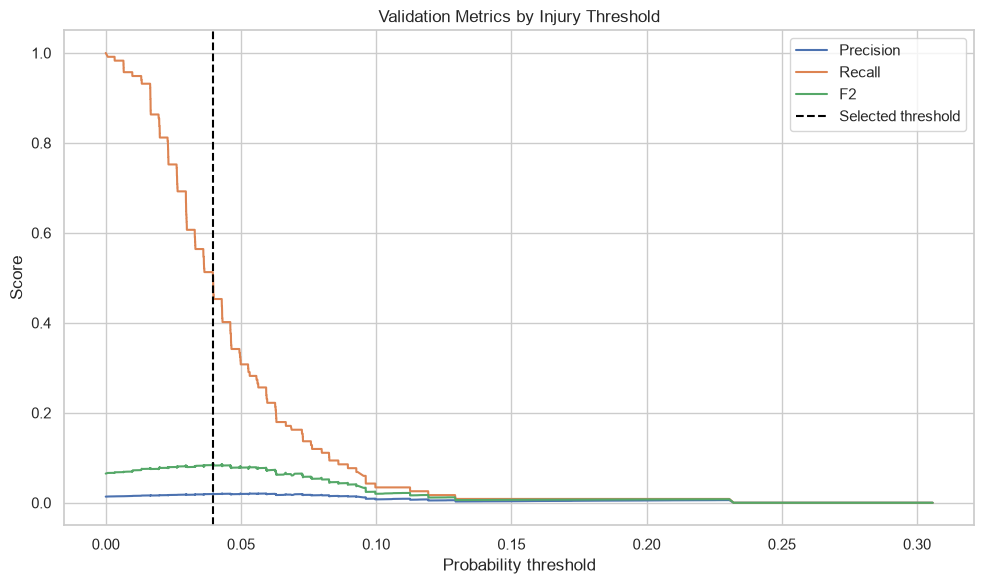

In [34]:
plt.figure(figsize=(10, 6))

plt.plot(
    threshold_analysis_df[
        "threshold"
    ],
    threshold_analysis_df[
        "precision"
    ],
    label="Precision"
)

plt.plot(
    threshold_analysis_df[
        "threshold"
    ],
    threshold_analysis_df[
        "recall"
    ],
    label="Recall"
)

plt.plot(
    threshold_analysis_df[
        "threshold"
    ],
    threshold_analysis_df[
        "f2"
    ],
    label="F2"
)

plt.axvline(
    selected_threshold,
    color="black",
    linestyle="--",
    label="Selected threshold"
)

plt.title(
    "Validation Metrics by Injury Threshold"
)
plt.xlabel("Probability threshold")
plt.ylabel("Score")
plt.legend()
plt.tight_layout()
plt.show()

### Threshold selection findings

The validation procedure selected a very low probability threshold of 0.0397.

At this threshold:

- Precision: 2.06%;
- Recall: 50.43%;
- F2-score: 0.088;
- Validation alert rate: 33.59%;
- Injury observations: 117;
- Observations predicted as injury: 2,870.

The model correctly identified approximately 59 of the 117 injuries and
missed approximately 58. However, only 59 of its 2,870 alerts were correct,
leaving approximately 2,811 false positives.

The threshold was much lower than 0.50 because the rare injury outcome caused
predicted probabilities to remain small. Class weighting increased the
importance of injuries during training but did not guarantee well-calibrated
probabilities.

Although lowering the threshold increased recall, it required generating
roughly 48 false alerts for every correctly identified injury. The selected
threshold therefore represented a weak validation trade-off rather than
strong predictive performance.

In [35]:
test_probabilities = (
    random_forest_pipeline
    .predict_proba(X_test)[:, 1]
)

default_test_predictions = (
    test_probabilities >= 0.50
).astype(int)

selected_test_predictions = (
    test_probabilities
    >= selected_threshold
).astype(int)

baseline_test_predictions = (
    baseline_pipeline
    .predict(X_test)
)

baseline_test_probabilities = (
    baseline_pipeline
    .predict_proba(X_test)[:, 1]
)

test_evaluation_df = pd.DataFrame(
    [
        calculate_metrics(
            "Majority baseline",
            y_test,
            baseline_test_predictions,
            baseline_test_probabilities
        ),
        calculate_metrics(
            "Random Forest — 0.50",
            y_test,
            default_test_predictions,
            test_probabilities
        ),
        calculate_metrics(
            (
                "Random Forest — selected "
                f"{selected_threshold:.4f}"
            ),
            y_test,
            selected_test_predictions,
            test_probabilities
        )
    ]
)

test_evaluation_df

,evaluation,accuracy,balanced_accuracy,precision,recall,f1,f2,roc_auc,average_precision
0,Majority baseline,0.986629,0.500000,0.000000,0.000000,0.000000,0.000000,0.500000,0.013371
1,Random Forest — 0.50,0.986629,0.500000,0.000000,0.000000,0.000000,0.000000,0.521011,0.013278
2,Random Forest — selected 0.0397,0.730471,0.499981,0.013369,0.263158,0.025445,0.055556,0.521011,0.013278


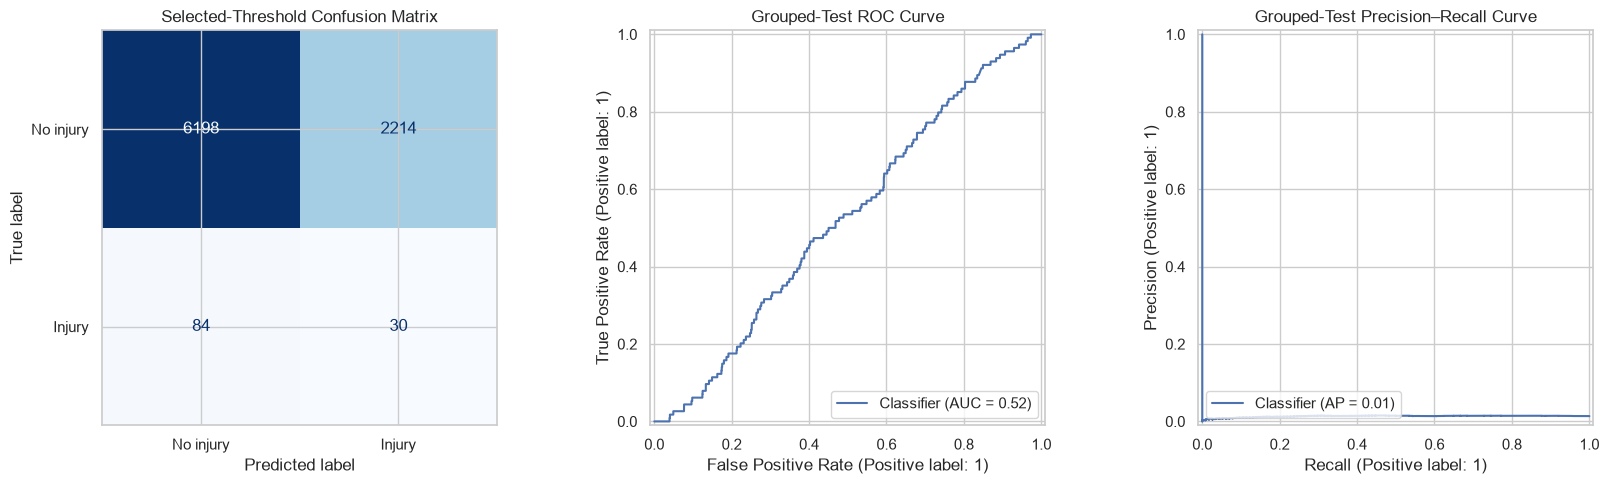

In [36]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(17, 5)
)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    selected_test_predictions,
    display_labels=[
        "No injury",
        "Injury"
    ],
    cmap="Blues",
    colorbar=False,
    ax=axes[0]
)

axes[0].set_title(
    "Selected-Threshold Confusion Matrix"
)

RocCurveDisplay.from_predictions(
    y_test,
    test_probabilities,
    ax=axes[1]
)

axes[1].set_title(
    "Grouped-Test ROC Curve"
)

PrecisionRecallDisplay.from_predictions(
    y_test,
    test_probabilities,
    ax=axes[2]
)

axes[2].set_title(
    "Grouped-Test Precision–Recall Curve"
)

plt.tight_layout()
plt.show()

### Final test findings

The grouped test set contained 114 injuries among 8,526 observations, giving
an injury prevalence of 1.34%.

Both the majority baseline and the Random Forest at threshold 0.50 predicted
no injuries. They achieved 98.66% accuracy but zero precision, recall, F1 and
F2.

At the selected threshold of 0.0397, the confusion matrix contained:

- True negatives: 6,198;
- False positives: 2,214;
- False negatives: 84;
- True positives: 30.

The selected-threshold performance was:

- Accuracy: 73.05%;
- Balanced accuracy: 50.00%;
- Precision: 1.34%;
- Recall: 26.32%;
- F1-score: 0.025;
- F2-score: 0.056;
- ROC-AUC: 0.521;
- Average precision: 0.0133.

The model generated 2,244 injury alerts but only 30 were correct. This is
approximately one correct injury case for every 75 alerts. It also missed 84
of the 114 actual injuries.

The average precision was slightly below the 1.34% test injury prevalence,
and balanced accuracy remained approximately 50%. The model therefore did
not generalise meaningfully to unseen runners.

In practice, the false negatives could create false reassurance, while the
large number of false positives could produce unnecessary concern or
training interruptions. The model is not suitable for operational or medical
use.

In [37]:
test_results_df = pd.DataFrame(
    {
        "athlete_id":
            groups_test.to_numpy(),
        "actual":
            y_test.to_numpy(),
        "prediction":
            selected_test_predictions,
        "probability":
            test_probabilities
    }
)

test_results_df["true_positive"] = (
    (
        test_results_df["actual"] == 1
    )
    & (
        test_results_df[
            "prediction"
        ] == 1
    )
).astype(int)

test_results_df["false_negative"] = (
    (
        test_results_df["actual"] == 1
    )
    & (
        test_results_df[
            "prediction"
        ] == 0
    )
).astype(int)

test_results_df["false_positive"] = (
    (
        test_results_df["actual"] == 0
    )
    & (
        test_results_df[
            "prediction"
        ] == 1
    )
).astype(int)

In [38]:
runner_test_summary_df = (
    test_results_df
    .groupby(
        "athlete_id",
        observed=True
    )
    .agg(
        records=("actual", "size"),
        injuries=("actual", "sum"),
        predicted_alerts=(
            "prediction",
            "sum"
        ),
        true_positives=(
            "true_positive",
            "sum"
        ),
        false_negatives=(
            "false_negative",
            "sum"
        ),
        false_positives=(
            "false_positive",
            "sum"
        ),
        mean_probability=(
            "probability",
            "mean"
        )
    )
    .reset_index()
)

runner_test_summary_df[
    "injury_recall"
] = np.where(
    runner_test_summary_df[
        "injuries"
    ] > 0,
    (
        runner_test_summary_df[
            "true_positives"
        ]
        / runner_test_summary_df[
            "injuries"
        ]
    ),
    np.nan
)

runner_test_summary_df.sort_values(
    [
        "injuries",
        "records"
    ],
    ascending=False
)

,athlete_id,records,injuries,predicted_alerts,true_positives,false_negatives,false_positives,mean_probability,injury_recall
4,29,730,33,101,7,26,94,0.021653,0.212121
7,38,843,18,357,6,12,351,0.043256,0.333333
5,32,1791,13,293,2,11,291,0.025412,0.153846
8,47,1072,13,106,1,12,105,0.021462,0.076923
10,54,1207,8,440,5,3,435,0.039078,0.625000
0,0,310,7,52,2,5,50,0.045642,0.285714
2,8,268,7,89,2,5,87,0.035091,0.285714
9,48,381,4,46,0,4,46,0.027406,0.000000
13,69,313,4,106,2,2,104,0.034932,0.500000
1,3,344,3,99,2,1,97,0.034547,0.666667


### Runner level error findings

The grouped test set contained 14 completely unseen runners. Thirteen had at
least one injury, while one runner had no recorded injuries.

Performance varied considerably:

- Runner 3 achieved 66.7% recall, detecting 2 of 3 injuries;
- Runner 54 achieved 62.5% recall, detecting 5 of 8;
- Runner 69 achieved 50.0% recall, detecting 2 of 4;
- Runner 47 achieved only 7.7% recall, detecting 1 of 13;
- Runners 48, 34 and 55 had zero recall;
- Runner 29 had the most injuries, but only 7 of 33 were detected.

False alerts were also unevenly distributed:

- Runner 54 received 435 false alerts;
- Runner 38 received 351;
- Runner 32 received 291;
- Runner 34 received 288;
- Runner 63 received 232.

Runner 34 was particularly problematic: the runner's only injury was missed,
while 288 non-injury records were incorrectly flagged. Runner 12 had no
injuries but still received 19 alerts.

These results indicate substantial runner-level distribution differences.
Aggregate recall of 26.3% hides the fact that the model performed moderately
for a few runners and completely failed for others. The predicted
probabilities were not equally meaningful across athletes.

In [39]:
fitted_forest = (
    random_forest_pipeline
    .named_steps["classifier"]
)

feature_importance_df = (
    pd.DataFrame(
        {
            "feature": X.columns,
            "importance":
                fitted_forest
                .feature_importances_
        }
    )
    .sort_values(
        "importance",
        ascending=False
    )
    .reset_index(drop=True)
)

feature_importance_df.head(20)

,feature,importance
0,avg_exertion,0.031963
1,max_exertion_2,0.029931
2,max_exertion,0.028354
3,total_km_z3_z4_z5_t1_t2,0.027570
4,max_km_one_day,0.026602
5,total_kms,0.025542
6,max_exertion_1,0.023128
7,max_km_one_day_1,0.022517
8,total_kms_1,0.022466
9,rel_total_kms_week_0_2,0.021913


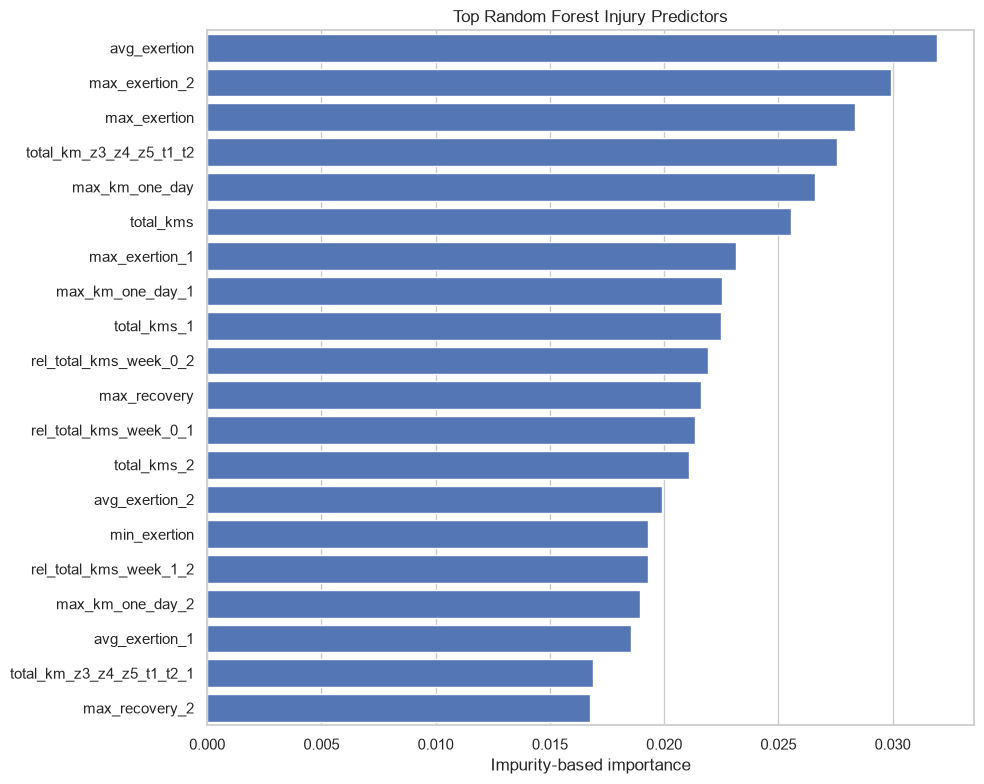

In [40]:
plt.figure(figsize=(10, 8))

sns.barplot(
    data=feature_importance_df.head(20),
    x="importance",
    y="feature",
    color="#4472C4"
)

plt.title(
    "Top Random Forest Injury Predictors"
)
plt.xlabel("Impurity-based importance")
plt.ylabel("")
plt.tight_layout()
plt.show()

### Feature importance 

The most influential Random Forest features were:

1. Current average exertion: 3.20%;
2. Older-period maximum exertion: 2.99%;
3. Current maximum exertion: 2.84%;
4. Current high-intensity running distance: 2.76%;
5. Current maximum one-day distance: 2.66%;
6. Current total running distance: 2.55%;
7. Previous-period maximum exertion: 2.31%;
8. Previous-period maximum one-day distance: 2.25%;
9. Previous-period total distance: 2.25%;
10. Relative distance between current and older weeks: 2.19%.

Exertion, total mileage, maximum daily distance, high-intensity mileage and
relative changes in weekly distance appeared repeatedly among the most
important variables. Recovery measurements also appeared, but with smaller
importance.

Current, previous and older training periods were all represented in the top
20. This suggests that the model used both recent load and historical
patterns rather than relying on one period alone.

Importance was broadly distributed. No feature contributed more than 3.2%,
and the top 20 together accounted for approximately 45.4% of total
importance. This is consistent with injury risk being multifactorial, but it
may also reflect correlated versions of the same measurements across several
weekly periods.

These values show which variables the fitted forest used for its splits. They
do not demonstrate that exertion or mileage caused injuries. Impurity-based
importance can also be biased toward continuous variables with many possible
split points and can divide importance across correlated features.

## Conclusion
Although the final model was not successful, the notebook demonstrates an
important machine-learning lesson: an apparently reasonable result under
random splitting can disappear when repeated individuals are separated
correctly. Reporting this failure is more informative than presenting the
inflated random-split result as evidence of a useful injury model.

Important limitations include:

- extremely rare injury outcomes;
- unequal numbers of records per runner;
- data from only one competitive running team;
- subjective exertion and recovery measurements;
- extreme values in relative-mileage variables;
- possible differences in how runners report training;
- no external team or prospective validation;
- no reliable probability calibration for unseen athletes.

Future work should use repeated grouped cross-validation, athlete-normalised
features, careful treatment of extreme mileage ratios, temporal validation,
probability calibration and external data from another team. Separate models
could also distinguish between population-level prediction for new runners
and personalised forecasting for runners with an established history.